In [1]:
# iterative value imputer
# method linear regression

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import torch.optim as optim

# generating synthetic data points

torch.manual_seed(25)
num_rows=15



In [2]:
arr=np.loadtxt("names.txt",dtype=str)
print(arr)

['emma' 'olivia' 'ava' ... 'zyrie' 'zyron' 'zzyzx']


In [3]:
# now we want to have more context that just the previous letter like we had earlier

# data preparation

import string


chars = ['.'] + list(string.ascii_lowercase)

stoi = {ch: i for i, ch in enumerate(chars)} # basically enumerate returns a pair index,char
itos = {i: ch for ch, i in stoi.items()}

block_size=3

X=[]
Y=[]

for w in arr:
  context=[0]*block_size
  for ch in w+'.':
    ix=stoi[ch]
    X.append(context)
    Y.append(ix)
    context=context[1:]+[ix] # crop and append

X=torch.tensor(X)
Y=torch.tensor(Y)
print(X.shape,Y.shape)


torch.Size([228146, 3]) torch.Size([228146])


In [4]:
print(X[1],Y[1])

tensor([0, 0, 5]) tensor(13)


In [5]:
# make embeddings of each letter in two dimensional sapce
# so instead of stoi we use these embeddings
torch.manual_seed(25)
embedding_dimesion=2
C=torch.randn((27,embedding_dimesion))

print(C)


tensor([[ 0.0877, -0.6113],
        [ 0.3441, -1.2916],
        [-0.5874,  0.8060],
        [ 1.3200,  0.4826],
        [ 1.6671, -0.2342],
        [ 0.1074,  1.7852],
        [ 0.7874, -0.2466],
        [ 0.2384, -0.6746],
        [-0.9314,  0.5380],
        [ 1.8837,  1.2911],
        [-0.1041, -0.6025],
        [-0.7860,  0.4670],
        [ 0.3695,  1.0820],
        [-1.9087,  1.6108],
        [ 0.0211, -0.6054],
        [ 2.2265, -1.7176],
        [ 0.1845, -0.1699],
        [ 0.4921, -0.7925],
        [ 1.6591, -0.0074],
        [-0.8333,  0.7151],
        [-1.5218,  0.1531],
        [ 0.0445, -1.4806],
        [ 0.1826, -0.1623],
        [ 0.1577,  0.2475],
        [ 0.8274, -1.7458],
        [-1.9661, -1.1676],
        [ 0.4603,  0.7549]])


In [6]:
# now embedding of some char is C[stoi[ch]]

# embed the tensor
emb=C[X]
print(emb.shape)

torch.Size([228146, 3, 2])


In [7]:
print(emb[0])
# we would maybe also want to learn a more sensible embedding as we carry on ahead

tensor([[ 0.0877, -0.6113],
        [ 0.0877, -0.6113],
        [ 0.0877, -0.6113]])


In [8]:
hidden_layers_size=100
W1=torch.randn((embedding_dimesion*block_size,hidden_layers_size)) # hidden layer with 100 nodes
b1=torch.randn(hidden_layers_size)

In [9]:
# now let's compute the hidden layer
hidden_layer=torch.tanh(emb.view((emb.shape[0],6)) @ W1 + b1)
print(hidden_layer.shape)

torch.Size([228146, 100])


In [10]:
hidden_layer=torch.tanh(emb.view((-1,6)) @ W1 + b1)
print(hidden_layer.shape)

torch.Size([228146, 100])


In [11]:
b1.shape # this is broadcasted while additon

torch.Size([100])

In [12]:
W2 = torch.randn((hidden_layers_size, 27))
b2 = torch.randn(27)
logits = hidden_layer @ W2 + b2
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

In [13]:
print(probs)

tensor([[5.6850e-07, 1.1937e-09, 1.0358e-09,  ..., 9.4472e-01, 4.7625e-10,
         6.8179e-11],
        [3.6318e-12, 2.6445e-08, 2.2082e-10,  ..., 7.9972e-03, 1.7788e-09,
         1.2143e-12],
        [1.5478e-16, 3.3624e-06, 4.9819e-11,  ..., 3.3449e-11, 1.9066e-04,
         9.9137e-11],
        ...,
        [9.3281e-14, 1.0129e-09, 2.1570e-08,  ..., 2.3940e-10, 1.4042e-09,
         3.4696e-12],
        [8.7904e-11, 3.1228e-16, 6.3246e-08,  ..., 2.1934e-10, 3.4907e-07,
         7.0616e-16],
        [4.6314e-09, 1.3653e-03, 2.4671e-09,  ..., 6.2710e-12, 4.1654e-06,
         2.8443e-04]])


In [14]:
ix=6
vec = torch.tensor([[0]*3])
print(vec)
torch.cat((vec[:,1:],torch.tensor([[ix]])),dim=1)


tensor([[0, 0, 0]])


tensor([[0, 0, 6]])

In [15]:
# let's train a neural network over this context understanding
# we have already prepared the X and Y vector
hidden_size=100

class MLP(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.C = torch.nn.Embedding(27, embedding_dimesion)

        self.fc1 = torch.nn.Linear(
            block_size*embedding_dimesion,
            hidden_size
        )

        self.fc2 = torch.nn.Linear(
            hidden_size,
            27
        )

    def forward(self, X):

        emb = self.C(X)

        x = emb.view(X.shape[0], -1)

        h = torch.tanh(self.fc1(x))

        logits = self.fc2(h)

        return logits

model = MLP()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

for step in range(10000):
    ix = torch.randint(0, X.shape[0], (64,))
    X1 = X[ix]
    Y1 = Y[ix]

    logits = model(X1)
    loss = F.cross_entropy(logits, Y1)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 1000 == 0:
        with torch.no_grad():
            global_logits = model(X)
            global_loss = F.cross_entropy(global_logits, Y)

        print(f"step={step:5d} global_loss={global_loss.item():.4f}")

step=    0 global_loss=3.2646
step= 1000 global_loss=2.5606
step= 2000 global_loss=2.4842
step= 3000 global_loss=2.4413
step= 4000 global_loss=2.4129
step= 5000 global_loss=2.3974
step= 6000 global_loss=2.3868
step= 7000 global_loss=2.3712
step= 8000 global_loss=2.3657
step= 9000 global_loss=2.3625


In [16]:
# let's see model predictions
# let's see the predictions
for _ in range(20):
  s=""
  vec = torch.tensor([[0] * 3])
  while(True):
    logits = model(vec)
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    ix = torch.multinomial(probs, num_samples=1).item()
    if ix == 0:
      break
    s += itos[ix]
    vec = torch.cat((vec[:, 1:], torch.tensor([[ix]])), dim=1)
  print(s)

arcon
lorin
cebseyshler
ien
kswa
man
leerlisziste
zhcoso
lyssea
jajeris
perion
gmonia
rek
ryo
heie
juea
donsa
zariza
meyyahahiya
mano


### Probability that a training example is never seen

Suppose:

- Dataset size: $m = 250000$
- Batch size: $B = 64$
- Training steps: $T = 10000$

The total number of samples drawn is

$$
N = B \times T = 64 \times 10000 = 640000.
$$

For a particular example, the probability that it is **not selected** in a single draw is

$$
1 - \frac{1}{m}.
$$

After $N$ independent draws, the probability that it is **never selected** is

$$
\left(1-\frac{1}{m}\right)^N.
$$

Substituting the values:

$$
\left(1-\frac{1}{250000}\right)^{640000}.
$$

Using the approximation

$$
\left(1-\frac{1}{m}\right)^N \approx e^{-N/m},
$$

we obtain

$$
e^{-640000/250000}
=
e^{-2.56}
\approx 0.077.
$$

Therefore, the probability that an example is seen **at least once** is

$$
1 - 0.077 = 0.923.
$$

So approximately

$$
92.3\%
$$

of the dataset is expected to be seen at least once during training.

In [17]:
# batching

# 80% training 10 % validation 10% testing
def build_dataset(words):
  block_size=3
  X=[]
  Y=[]
  for w in words:
      context=[0]*block_size
      for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix] # crop and append
  X= torch. tensor(X)
  Y = torch. tensor(Y)
  print (X.shape, Y. shape)
  return X, Y


import random
random.seed(42)
random.shuffle(arr)
n1 = int(0.8*len(arr))
n2= int(0.9*len(arr))
Xtr, Ytr = build_dataset(arr[:n1])
Xdev,Ydev = build_dataset(arr[n1:n2])
Xte,Yte = build_dataset(arr[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [18]:
g=torch.Generator().manual_seed(2147483647)
C=torch.randn((27,2),generator=g)
W1=torch.randn((6,300),generator=g)
b1=torch.randn(300,generator=g)
W2=torch.randn((300,27),generator=g)
b2=torch.randn(27,generator=g)
parameters=[C,W1,b1,W2,b2]

In [19]:
sum(p.nelement() for p in parameters)

10281

In [20]:
for p in parameters:
  p.requires_grad=True

In [21]:
for i in range(30000):
  ix = torch.randint(0,Xtr.shape[0],(32,))
  emb = C[Xtr[ix]]
  h = emb.view(-1,6) @ W1 + b1
  h = torch.tanh(h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits,Ytr[ix])
  for p in parameters:
    p.grad=None

  loss.backward()
  lr=0.1
  for p in parameters:
    p.data += -lr*p.grad

# training loss
print(loss.item())

2.327639102935791


In [22]:
# train a bit more using lower learning rate
for i in range(30000):
  ix = torch.randint(0,Xtr.shape[0],(32,))
  emb = C[Xtr[ix]]
  h = emb.view(-1,6) @ W1 + b1
  h = torch.tanh(h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits,Ytr[ix])
  for p in parameters:
    p.grad=None

  loss.backward()
  lr=0.01
  for p in parameters:
    p.data += -lr*p.grad

# training loss
print(loss.item())

2.311713457107544


In [23]:
# testing loss

emb = C[Xte]
h = emb.view(-1,6) @ W1 + b1
h = torch.tanh(h)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Yte)

print(loss.item())

2.2954373359680176


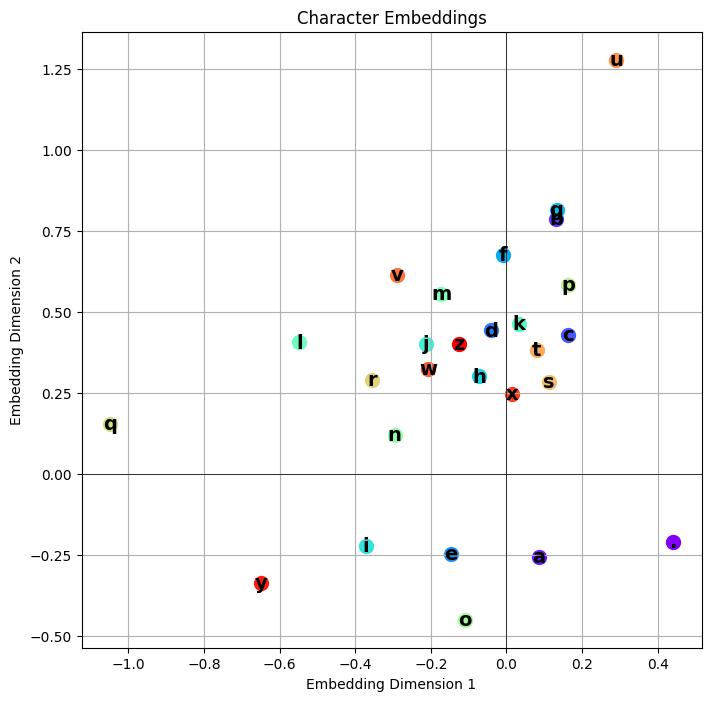

In [24]:
import numpy as np
import matplotlib.pyplot as plt

points = []
for i in range(27):
    points.append(C[i].detach().cpu().numpy())

points = np.array(points)

colors = plt.cm.rainbow(np.linspace(0, 1, len(points)))

plt.figure(figsize=(8, 8))

for i, (x, y) in enumerate(points):
    plt.scatter(x, y, color=colors[i], s=100)
    plt.text(
        x, y,
        itos[i],
        fontsize=14,
        ha='center',
        va='center',
        fontweight='bold'
    )

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.title("Character Embeddings")
plt.show()

Exercises Part-1

In [25]:
# initialising to get uniform distribution

# let's generate the parameters again
g=torch.Generator().manual_seed(2147483647)
C=torch.randn((27,2),generator=g)
W1=torch.randn((6,300),generator=g)
b1=torch.randn(300,generator=g)
W2=torch.randn((300,27),generator=g)
b2=torch.randn(27,generator=g)
parameters=[C,W1,b1,W2,b2]

# and let's just see the cross entropy loss on the training dataset

for p in parameters:
  p.requires_grad=False

emb = C[Xtr]
h = emb.view(-1,6) @ W1 + b1
h = torch.tanh(h)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
print(loss)
print(Xtr.shape)
print(Ytr.shape)

tensor(26.0098)
torch.Size([182625, 3])
torch.Size([182625])


We expect an initial loss of log(27) which is around 3.2-3.5

In [26]:
# karapathy's approach is to just use a small second layer so as multiplication resluts in numbers closer to 0
# initialising to get uniform distribution

# let's generate the parameters again
g=torch.Generator().manual_seed(2147483647)
C=torch.randn((27,2),generator=g)
W1=torch.randn((6,300),generator=g)
b1=torch.randn(300,generator=g)
W2=torch.randn((300,27),generator=g) * 0.001
b2=torch.randn(27,generator=g) * 0.0
parameters=[C,W1,b1,W2,b2]

# and let's just see the cross entropy loss on the training dataset

for p in parameters:
  p.requires_grad=False

emb = C[Xtr]
h = emb.view(-1,6) @ W1 + b1
h = torch.tanh(h)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
print(loss)

tensor(3.2940)


Nice we find really optimal weights infact e^{3.2940}=26.95 so really close to 27

In [27]:
# let's look at some other ways we can do this
# I found one method online very similar to above but can easily be generalised and extended to multiple layers uisng the layer size

# LeCun-style variance preserving initialization
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27, 2), generator=g)

W1 = torch.randn((6, 300), generator=g) * (1 / 6) ** 0.5
b1 = torch.zeros(300)

W2 = torch.randn((300, 27), generator=g) * (1 / 300) ** 0.5
b2 = torch.zeros(27)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = False

emb = C[Xtr]
h = emb.view(-1, 6) @ W1 + b1
h = torch.tanh(h)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, Ytr)
print(loss)

tensor(3.4748)


Batch Normalisation


In [44]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27, 2), generator=g)

W1 = torch.randn((6, 300), generator=g) * (1 / 6) ** 0.5
b1 = torch.zeros(300)

W2 = torch.randn((300, 27), generator=g) * (1 / 300) ** 0.5
b2 = torch.zeros(27)

bngain = torch.ones((1, 300))
bnbias = torch.zeros((1, 300))


parameters = [C, W1, b1, W2, b2,bngain,bnbias]

for p in parameters:
    p.requires_grad = True



max_steps = 200000
batch_size = 32
lossi=[]

for i in range(max_steps):
  ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
  Xb,Yb=Xtr[ix],Ytr[ix]
  emb = C[Xb]
  emb_cat = emb.view(emb.shape[0],-1)
  hpreact = emb_cat @ W1 + b1
  hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits,Yb)

  # backward pass
  for p in parameters:
    p.grad=None

  loss.backward()
  lr = 0.1 if i<50000 else 0.01
  for p in parameters:
    p.data+= -lr*p.grad

  # track stats
  if(i%10000==0):
    print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000:3.1986
  10000/ 200000:2.3746
  20000/ 200000:2.3678
  30000/ 200000:2.3146
  40000/ 200000:2.5910
  50000/ 200000:2.4598
  60000/ 200000:2.2006
  70000/ 200000:2.5833
  80000/ 200000:2.0271
  90000/ 200000:2.4720
 100000/ 200000:2.0110
 110000/ 200000:2.2787
 120000/ 200000:2.2370
 130000/ 200000:2.2051
 140000/ 200000:2.2344
 150000/ 200000:2.3012
 160000/ 200000:2.3601
 170000/ 200000:2.4113
 180000/ 200000:2.1197
 190000/ 200000:2.2915


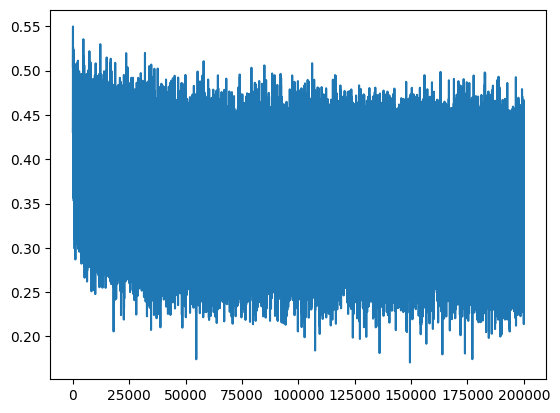

In [46]:
plt.plot(lossi)

In [45]:
# testing metrics

# we just need to do a forward pass over all all of the testing data

for p in parameters:
  p.requires_grad=False

emb = C[Xte]
emb_cat = emb.view(emb.shape[0],-1)
hpreact = emb_cat @ W1 + b1
hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Yte)
print(loss.item())

2.2322819232940674
